# **Fake News Detection Using Emotion Amplification and Knowledge Graphs on 'FakeNewsBlstm' Dataset**

**1. Import Required Libraries**

In [2]:
import pandas as pd
import numpy as np
import nltk
import re
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb

**2. Download NLTK Resources**

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

**3. Load Dataset**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/My Drive/FakeNewsBlstm.csv', encoding='ISO-8859-1')
df.columns = ['label_text', 'content']
df['label_text'] = df['label_text'].str.strip().str.lower()
df['label'] = df['label_text'].map({'real': 1, 'fake': 0})
df.dropna(subset=['label'], inplace=True)

**3. Clean Text**

In [6]:
def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = text.lower()
    return text

df['cleaned'] = df['content'].apply(clean_text)

**4. Use Simplified Emotion Lexicon**

In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [8]:
nrc = {
    'fear': ['fear', 'scared', 'afraid', 'terrified'],
    'joy': ['joy', 'happy', 'delight'],
    'anger': ['anger', 'mad', 'furious'],
    'trust': ['trust', 'faith', 'reliable'],
    'disgust': ['disgust', 'repel', 'nausea'],
    'surprise': ['surprise', 'shock', 'amaze'],
    'sadness': ['sadness', 'sorrow', 'cry'],
    'anticipation': ['anticipate', 'expect', 'await']
}

tqdm.pandas()
def amplify_sentiment(text):
    tokens = nltk.word_tokenize(text)
    emo_score = {k: 0 for k in nrc}
    for token in tokens:
        for emotion, keywords in nrc.items():
            if token in keywords:
                emo_score[emotion] += 1
    return list(emo_score.values())

emotion_features = df['cleaned'].progress_apply(amplify_sentiment)
emotion_df = pd.DataFrame(emotion_features.tolist(), columns=list(nrc.keys()))

  0%|          | 0/1470 [00:00<?, ?it/s]

**5. TF-IDF + Combine with Emotion Features**

In [9]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned'])
X_final = hstack([X_tfidf, emotion_df])
y = df['label']

**6: Split and Train Model**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb
from xgboost import XGBClassifier # Import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:12:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

**7: Evaluate Model**

In [11]:
y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n✅ Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.826530612244898

✅ Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.63      0.74       113
           1       0.80      0.95      0.87       181

    accuracy                           0.83       294
   macro avg       0.85      0.79      0.80       294
weighted avg       0.84      0.83      0.82       294



**8: Knowledge Graph Visualization**

In [12]:
import networkx as nx # Import the networkx library as nx
from nltk.corpus import stopwords # Import stopwords from nltk
import matplotlib.pyplot as plt # Import matplotlib.pyplot as plt

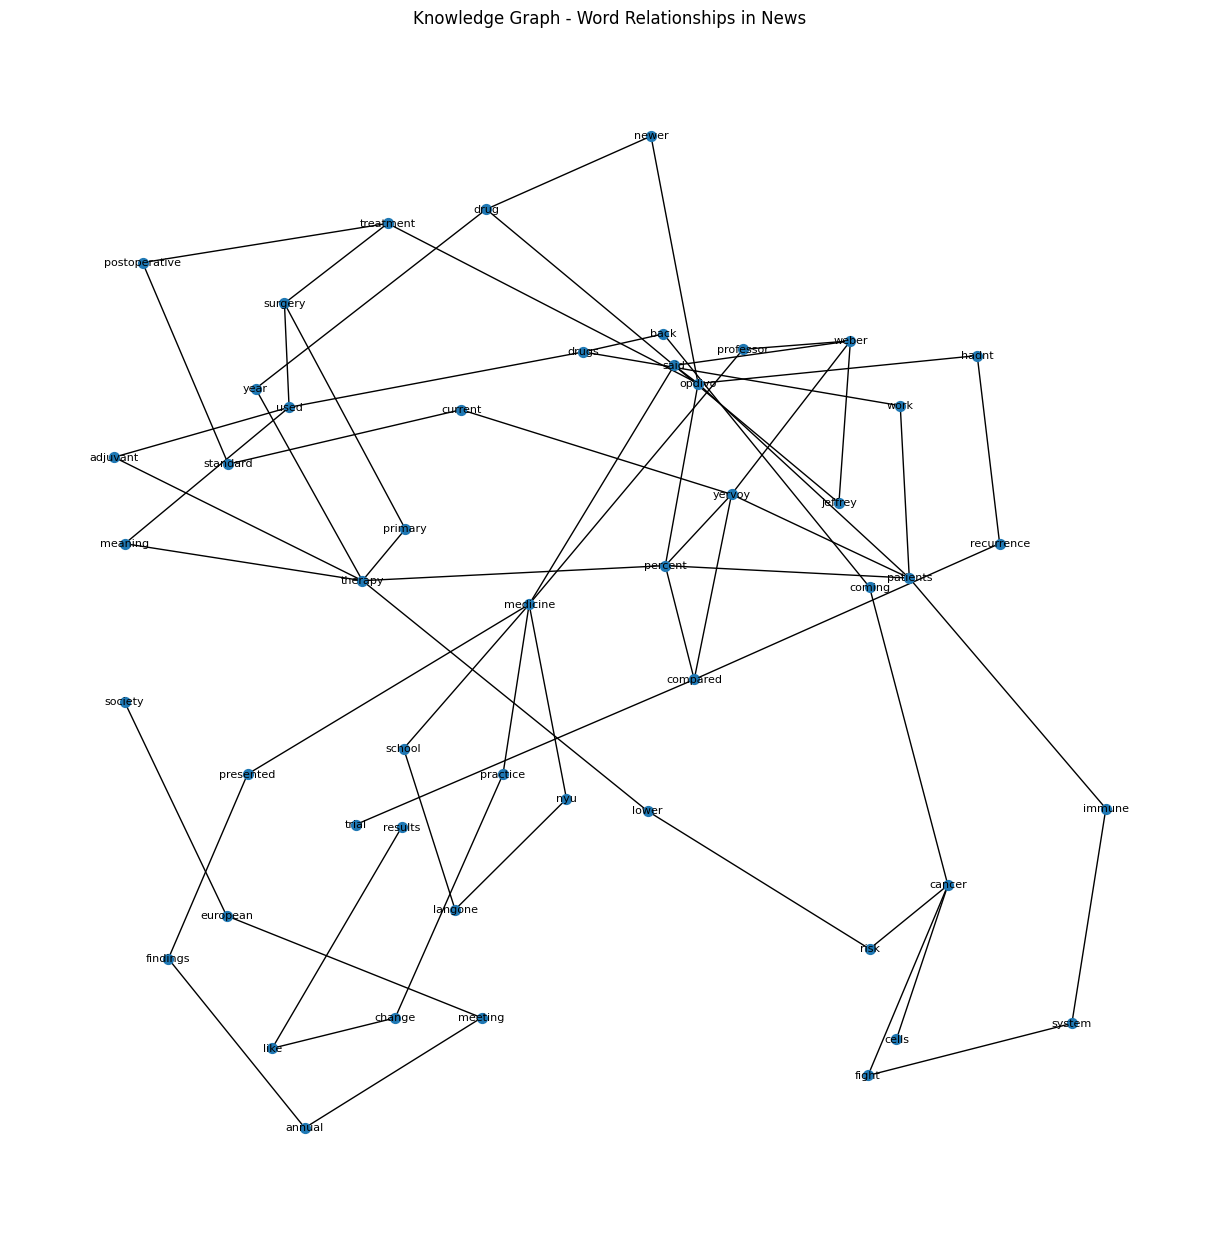

In [13]:
def build_kg(texts, max_articles=100):
    G = nx.Graph()
    stop_words = set(stopwords.words('english'))
    for text in texts[:max_articles]:
        sentences = nltk.sent_tokenize(text)
        for sentence in sentences:
            words = nltk.word_tokenize(sentence)
            words = [w.lower() for w in words if w.lower() not in stop_words and w.isalpha()]
            for i in range(len(words) - 1):
                G.add_edge(words[i], words[i + 1])
    return G

G = build_kg(df['cleaned'].tolist())
plt.figure(figsize=(12, 12))
subgraph = G.subgraph(list(G.nodes)[:50])
pos = nx.spring_layout(subgraph, k=0.5)
nx.draw(subgraph, pos, with_labels=True, node_size=50, font_size=8)
plt.title("Knowledge Graph - Word Relationships in News")
plt.show()